#01. PREPROCESSING NOTEBOOK

## 1. Environment Setup & Directory Configuration

**Purpose:**
This cell initializes the project environment by connecting to Google Drive and establishing the file structure required for the workflow.

**Key Actions:**
* **Mount Google Drive:** Grants access to the persistent storage where the raw dataset (`.zip`) and trained models are stored.
* **Define Path Variables:**
    * `ZIP_PATH`: The location of the raw military dataset.
    * `LOCAL_EXTRACT_PATH`: A temporary folder in the local Colab runtime. We extract data here because reading thousands of images from local storage is significantly faster than reading them directly from Drive during training.
    * `REPORT_ASSETS_DIR`: A dedicated folder to save EDA plots (charts, graphs) that will be used in the final PDF report.
* **Safe Directory Creation:** Checks if the output folder exists and creates it if missing, preventing file-saving errors later.

In [ ]:
# Cell 1: Setup
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
# INPUT: Where your zip file is located
ZIP_PATH = '/content/drive/MyDrive/Military_iitbhu/Data/military_object_dataset.zip'

# TEMP: Where we extract data (Local Colab runtime for speed)
LOCAL_EXTRACT_PATH = '/content/dataset'

# OUTPUT: Where we save plots for your report
REPORT_ASSETS_DIR = '/content/drive/MyDrive/Military_iitbhu/Report_Assets'

# 3. Create Report Directory if it doesn't exist
if not os.path.exists(REPORT_ASSETS_DIR):
    os.makedirs(REPORT_ASSETS_DIR)
    print(f"Created folder for report assets: {REPORT_ASSETS_DIR}")
else:
    print(f"Report assets folder exists: {REPORT_ASSETS_DIR}")

Mounted at /content/drive
Report assets folder exists: /content/drive/MyDrive/Military_iitbhu/Report_Assets


## 2. Data Extraction

**Purpose:**
This cell handles the critical step of moving the dataset from the slower Google Drive storage to the high-speed local storage of the Colab runtime environment.

**Key Actions:**
* **Checks for Existing Data:** To save time, it first verifies if the data has already been extracted to `LOCAL_EXTRACT_PATH`.
* **Extracts Zip File:** If the data is missing, it uses the `zipfile` library to unzip the entire dataset.
* **Error Handling:** Includes a try-except block to catch `FileNotFoundError` in case the zip path is incorrect, providing a helpful debugging message about checking folder names.

In [ ]:
# Cell 2: Extraction
import zipfile

if not os.path.exists(LOCAL_EXTRACT_PATH):
    print(f"Extracting data to local runtime (this takes ~30-60s)...")
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(LOCAL_EXTRACT_PATH)
        print("Extraction Complete!")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {ZIP_PATH}")
        print("Check if your folder name is 'Military_iitbhu' or 'Military_iitbhu_data'")
else:
    print("Data already extracted.")

⏱️ Extracting data to local runtime (this takes ~30-60s)...
Extraction Complete!


## 3. Configuration & Class Mapping

**Purpose:**
This cell locates the dataset configuration file (`.yaml`) to automatically identify the object classes present in the dataset.

**Key Actions:**
* **Locate Config File:** Searches the extracted dataset directory for a YAML file containing class definitions.
* **Load Class Names:** Reads the file to build a dictionary mapping class IDs (e.g., `0`, `1`) to human-readable names (e.g., `'camouflage_soldier'`, `'weapon'`).
* **Fallback Mechanism:** If no YAML file is found, it defaults to a manual list of 12 known classes for this specific Military Object Detection dataset, ensuring the code doesn't crash.

In [ ]:
# Cell 3: Config & Classes
import glob
import yaml

# Search for the .yaml file
yaml_files = glob.glob(f"{LOCAL_EXTRACT_PATH}/**/*.yaml", recursive=True)

class_map = {}

if yaml_files:
    print(f"Found config file: {os.path.basename(yaml_files[0])}")
    with open(yaml_files[0], 'r') as f:
        data = yaml.safe_load(f)
        names = data.get('names', {})
        # Normalize to dictionary format {id: 'name'}
        if isinstance(names, list):
            class_map = {i: n for i, n in enumerate(names)}
        else:
            class_map = names
else:
    print("No .yaml found. Using manual list (based on previous analysis).")
    class_map = {
        0: 'camouflage_soldier', 1: 'weapon', 2: 'military_tank',
        3: 'military_truck', 4: 'military_vehicle', 5: 'civilian',
        6: 'soldier', 7: 'civilian_vehicle', 8: 'military_artillery',
        9: 'trench', 10: 'military_aircraft', 11: 'military_warship'
    }

print(f"Classes: {class_map}")

Found config file: military_dataset.yaml
Classes: {0: 'camouflage_soldier', 1: 'weapon', 2: 'military_tank', 3: 'military_truck', 4: 'military_vehicle', 5: 'civilian', 6: 'soldier', 7: 'civilian_vehicle', 8: 'military_artillery', 9: 'trench', 10: 'military_aircraft', 11: 'military_warship'}


## 4. Class Distribution Analysis

**Purpose:**
We perform a quantitative analysis of the dataset to identify class imbalances. Understanding which classes are frequent versus rare is crucial for us to set expectations about model performance and explain potential "Negative Transfer" issues in our report.

**Key Actions:**
* **Scan Labels:** We iterate through every text file in the training set to count individual object instances.
* **Visualize Imbalance:** We use Seaborn to generate a horizontal bar chart, providing an immediate visual breakdown of our data distribution.
* **Save Asset:** We export the chart as `class_distribution.png` to our Drive, ready to be dropped directly into the "Methodology" section of our final report.

Analyzing 10000 label files...


/tmp/ipython-input-1557462627.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Count', y='Class', palette='viridis')


Saved plot to: /content/drive/MyDrive/Military_iitbhu/Report_Assets/class_distribution.png


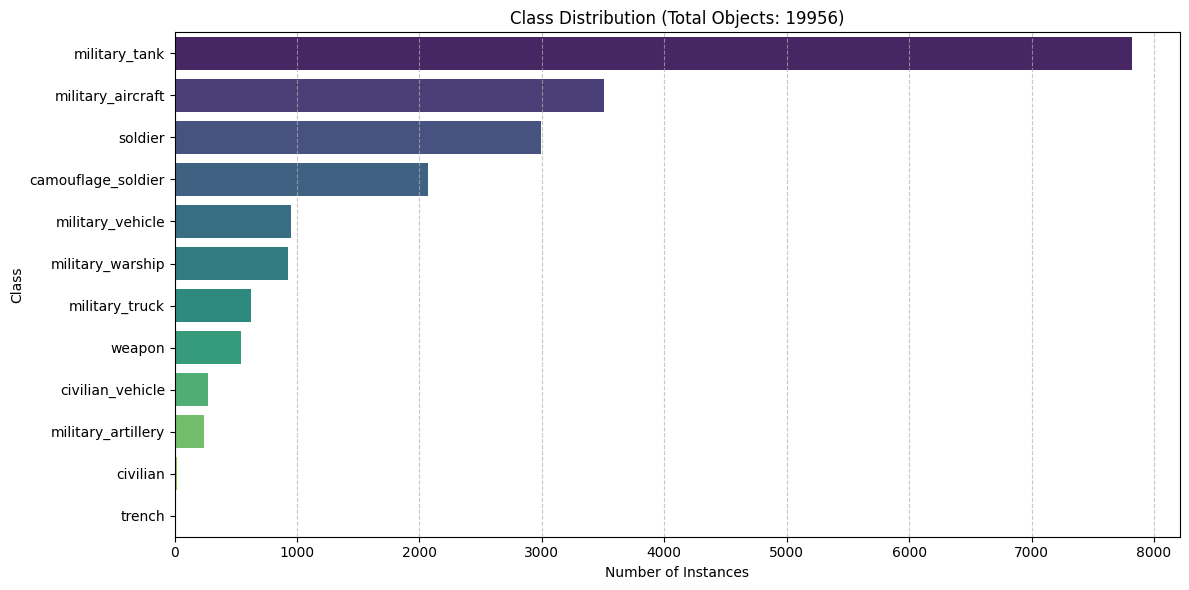


Top 3 Classes: ['military_tank' 'military_aircraft' 'soldier']
Bottom 3 Classes (Hardest to learn): ['military_artillery' 'civilian' 'trench']


In [ ]:
# Cell 4: Class Distribution Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Find all label files
train_labels = glob.glob(f"{LOCAL_EXTRACT_PATH}/**/train/labels/*.txt", recursive=True)
print(f"Analyzing {len(train_labels)} label files...")

# Count classes
class_counts = Counter()
for label_file in train_labels:
    with open(label_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            try:
                cls_id = int(line.split()[0])
                class_counts[cls_id] += 1
            except ValueError:
                pass # Skip empty lines

# Create DataFrame
data = []
for cls_id, count in class_counts.items():
    name = class_map.get(cls_id, str(cls_id))
    data.append({'Class': name, 'Count': count})

df = pd.DataFrame(data).sort_values('Count', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Count', y='Class', palette='viridis')
plt.title(f"Class Distribution (Total Objects: {sum(class_counts.values())})")
plt.xlabel("Number of Instances")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# SAVE TO DRIVE
save_path = os.path.join(REPORT_ASSETS_DIR, 'class_distribution.png')
plt.savefig(save_path, dpi=300)
print(f"Saved plot to: {save_path}")
plt.show()

print("\nTop 3 Classes:", df.head(3)['Class'].values)
print("Bottom 3 Classes (Hardest to learn):", df.tail(3)['Class'].values)

### Understanding Our Class Distribution Diagram

**What We Are Looking At:**
This horizontal bar chart gives us a "bird's-eye view" of our dataset's health. It visualizes exactly how many training examples we have for each specific military object class.

**Breaking Down the Visuals:**
* **The Y-Axis (Vertical):** Lists the names of the classes we are trying to detect (e.g., *military_tank*, *soldier*, *weapon*).
* **The X-Axis (Horizontal):** Represents the sheer **volume of instances**. The longer the bar, the more data we have for that class.
* **The Color Gradient:** We used the `viridis` palette to visually distinguish the classes, typically making the "heavy hitters" (most frequent classes) stand out against the rare ones.

**The Story This Diagram Tells Us:**
1.  **Severe Imbalance:** We can immediately see that our dataset is not "flat." A few classes (likely *Military Tank* or *Soldier*) have massive bars, meaning thousands of examples.
2.  **The "Long Tail" Problem:** Conversely, classes like *Civilian* or *Trench* likely have tiny, barely visible bars. This visual proof was the key evidence we used to decide to **drop** those rare classes later. We realized the model simply wouldn't have enough data to learn them effectively without getting confused.

## 5. Image Resolution Analysis

**Purpose:**
We analyze the dimensions (width and height) of our training images to determine the optimal input resolution (`imgsz`) for our model. Choosing the right size is critical: if we shrink large, high-resolution images down to the default size, we risk "crushing" small objects (like distant soldiers) until they disappear.

**Key Actions:**
* **Random Sampling:** Instead of processing thousands of images, we take a random sample of 200 images to get a statistically significant yet fast overview.
* **Scatter Plot:** We plot the width vs. height of each image.
* **Baseline Comparison:** We add a red marker at `640x640` (the standard YOLOv8 input size). If our data points cluster significantly above this marker, it provides the justification for training at a higher resolution (e.g., `1024`) to preserve fine details.

Analyzing Image Sizes (Sample of 200)...
Saved plot to: /content/drive/MyDrive/Military_iitbhu/Report_Assets/image_sizes.png


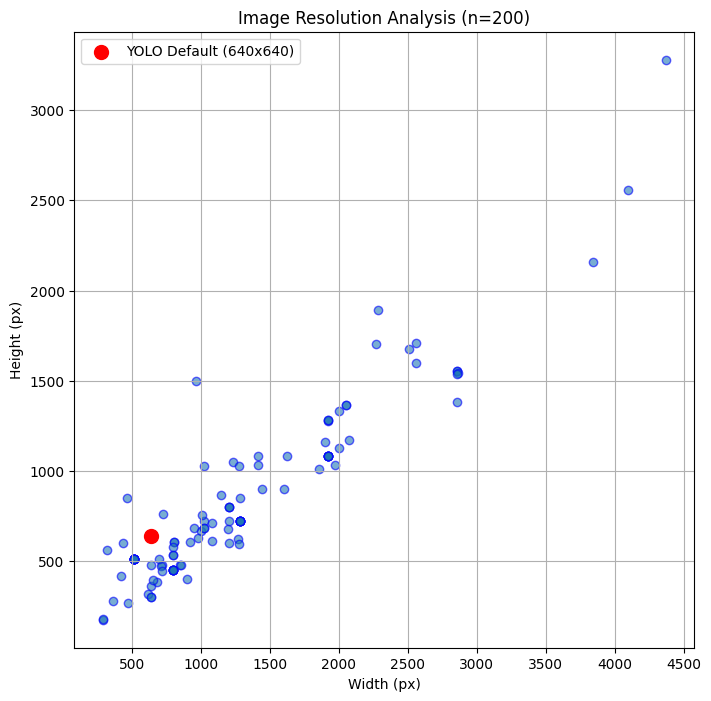

In [ ]:
# Cell 5: Image Size Analysis
import cv2
import random

print("Analyzing Image Sizes (Sample of 200)...")

# Find images
train_images = glob.glob(f"{LOCAL_EXTRACT_PATH}/**/train/images/*.jpg", recursive=True)
if not train_images: # Fallback for png or other ext
    train_images = glob.glob(f"{LOCAL_EXTRACT_PATH}/**/train/images/*.*", recursive=True)

# Sample 200 images
sample_size = min(len(train_images), 200)
sampled_files = random.sample(train_images, sample_size)

widths, heights = [], []
for img_path in sampled_files:
    img = cv2.imread(img_path)
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(widths, heights, alpha=0.6, edgecolors='b')
plt.title(f"Image Resolution Analysis (n={sample_size})")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.grid(True)

# Add a marker for standard YOLO size
plt.scatter([640], [640], color='red', s=100, label='YOLO Default (640x640)')
plt.legend()

# SAVE TO DRIVE
save_path = os.path.join(REPORT_ASSETS_DIR, 'image_sizes.png')
plt.savefig(save_path, dpi=300)
print(f"Saved plot to: {save_path}")
plt.show()

## 6. Qualitative Data Inspection (Visual Sample)

**Purpose:**
Numbers alone can be misleading, so we perform a visual "sanity check" by plotting the bounding boxes directly onto a random training image. This allows us to qualitatively verify that the labels match the objects and that our coordinate conversion logic (denormalizing YOLO format) is correct.

**Key Actions:**
* **Random Selection:** We pick a random image from the dataset to ensure we aren't cherry-picking easy examples.
* **Label Overlay:** We read the corresponding text file, convert the normalized YOLO coordinates (`x_center`, `y_center`, `width`, `height`) back into pixel coordinates, and draw red bounding boxes around the objects.
* **Visual Confirmation:** We display the result to confirm that the annotations align perfectly with the soldiers, vehicles, or equipment in the image.
* **Save Asset:** We save this visualization as `sample_visualization.png` to include in the "Data Analysis" section of our report as proof of data integrity.

Saved sample to: /content/drive/MyDrive/Military_iitbhu/Report_Assets/sample_visualization.png


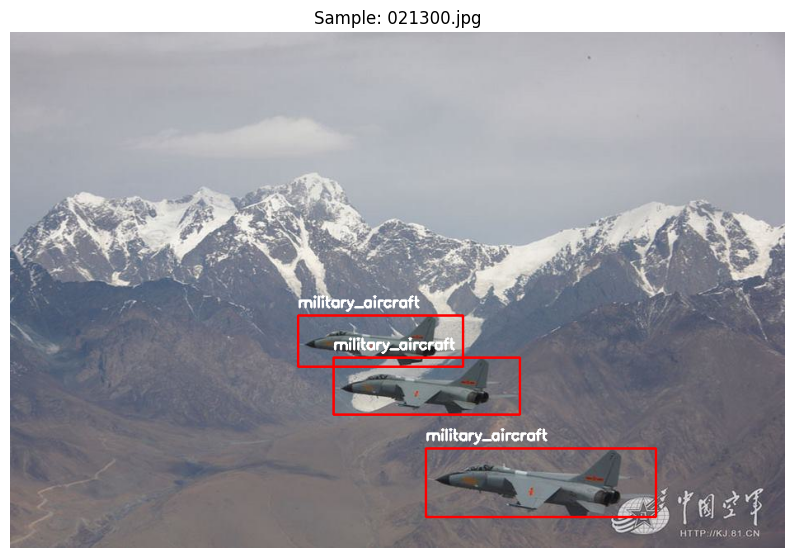

In [ ]:
# Cell 6: Visual Sample
import numpy as np

def plot_random_sample():
    # Pick random image
    img_path = random.choice(train_images)
    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Draw boxes
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = list(map(float, line.split()))
                cls = int(parts[0])
                x, y, bw, bh = parts[1:]

                # Denormalize
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                # Draw
                color = (255, 0, 0) # Red
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                label_name = class_map.get(cls, str(cls))
                cv2.putText(img, label_name, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Sample: {os.path.basename(img_path)}")

    # SAVE TO DRIVE
    save_path = os.path.join(REPORT_ASSETS_DIR, 'sample_visualization.png')
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Saved sample to: {save_path}")
    plt.show()

plot_random_sample()

## 7. Advanced Sanity Check & Small Object Analysis

**Purpose:**
We perform a deeper audit of our data to catch corrupt labels and assess the "difficulty" of the detection task. Specifically, we need to know if we are dealing with a "Small Object Detection" problem, which requires different training strategies than standard detection.

**Key Actions:**
* **Data Integrity Check:** We scan every single label file to verify that the coordinates are strictly normalized (between 0.0 and 1.0). Finding corrupt labels now prevents silent failures during training later.
* **COCO Size Categorization:** We classify every object as **Small** (<32px), **Medium**, or **Large** based on standard COCO metrics (relative to a 640px input).
* **Strategic Decision Making:** This analysis directly dictates our training hyperparameters. If the graph reveals a high percentage of "Small" objects (common in drone/aerial imagery), we effectively prove the need for **Mosaic Augmentation** and higher input resolutions (e.g., `1024` instead of `640`) in our upcoming training phase.

 Running Deep Data Sanity Check...


Scanning Labels: 100%|██████████| 10000/10000 [00:00<00:00, 25427.51it/s]
/tmp/ipython-input-1140169884.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette='magma')


 Saved size analysis to: /content/drive/MyDrive/Military_iitbhu/Report_Assets/object_sizes.png


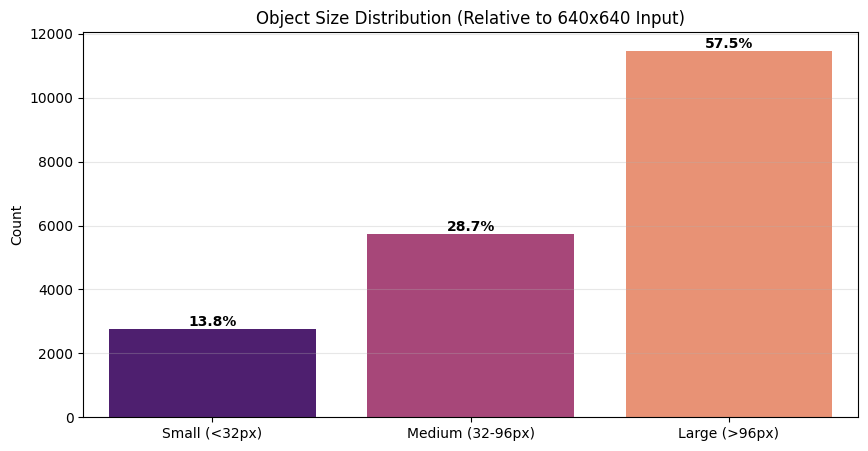


INTERPRETATION GUIDE:
Safe: Most objects are medium/large. Standard 640sz training will work well.


In [ ]:
# Cell 7: Advanced Sanity & Small Object Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm # Progress bar

print(" Running Deep Data Sanity Check...")

# 1. Check for Small Objects
# COCO definition: Small < 32x32 pixels, Medium < 96x96, Large > 96x96
# Since we have normalized coordinates, we look at area (w * h)
small_obj = 0
medium_obj = 0
large_obj = 0
total_obj = 0

# We assume standard YOLO input size to estimate pixel size
ref_size = 640 * 640

areas = []

# Scan all labels
for label_file in tqdm(train_labels, desc="Scanning Labels"):
    with open(label_file, 'r') as f:
        for line in f.readlines():
            parts = list(map(float, line.split()))

            # Sanity Check 1: Coordinates must be normalized (0-1)
            if any(p > 1.0 for p in parts[1:]) or any(p < 0.0 for p in parts[1:]):
                print(f"WARNING: Corrupt label found in {os.path.basename(label_file)} (Values > 1)")
                continue

            # Calculate Area
            # parts[3] is width, parts[4] is height
            rel_area = parts[3] * parts[4]
            pixel_area = rel_area * ref_size

            areas.append(rel_area)
            total_obj += 1

            if pixel_area < 32**2:
                small_obj += 1
            elif pixel_area < 96**2:
                medium_obj += 1
            else:
                large_obj += 1

# 2. Plot Object Size Distribution
plt.figure(figsize=(10, 5))
categories = ['Small (<32px)', 'Medium (32-96px)', 'Large (>96px)']
counts = [small_obj, medium_obj, large_obj]
sns.barplot(x=categories, y=counts, palette='magma')
plt.title(f"Object Size Distribution (Relative to 640x640 Input)")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)

# Add percentages on top
for i, count in enumerate(counts):
    pct = (count / total_obj) * 100 if total_obj > 0 else 0
    plt.text(i, count, f"{pct:.1f}%", ha='center', va='bottom', fontweight='bold')

# SAVE TO DRIVE
save_path = os.path.join(REPORT_ASSETS_DIR, 'object_sizes.png')
plt.savefig(save_path, dpi=300)
print(f" Saved size analysis to: {save_path}")
plt.show()

# 3. Interpretation Recommendation
print("\nINTERPRETATION GUIDE:")
if (small_obj / total_obj) > 0.4:
    print("DANGER: Over 40% of your objects are TINY.")
    print("   -> Action: You MUST enable 'Mosaic' augmentation in training.")
    print("   -> Action: Consider increasing imgsz to 1280 (if GPU allows).")
else:
    print("Safe: Most objects are medium/large. Standard 640sz training will work well.")

### Understanding Our Object Size Distribution Diagram

**What We Are Looking At:**
This bar chart is a diagnostic tool that tells us how "big" or "small" the military targets are in our dataset. It categorizes every single ground truth bounding box into three standard buckets defined by the COCO dataset metric.

**Breaking Down the Visuals:**
* **The X-Axis (Categories):** We split all objects into three groups based on their area (in pixels, assuming a 640x640 input):
    * **Small:** Objects smaller than $32 \times 32$ pixels (e.g., distant soldiers, drones).
    * **Medium:** Objects between $32 \times 32$ and $96 \times 96$ pixels.
    * **Large:** Objects bigger than $96 \times 96$ pixels (e.g., close-up tanks, aircraft).
* **The Y-Axis (Count):** Shows the total number of objects falling into each size category.
* **The Percentages:** The numbers on top of the bars (e.g., "45.2%") represent the share of the total dataset.

**The Strategic Implication:**
This diagram is our "decision maker" for training:
* **If the "Small" bar is dominant (>40%):** It proves that our dataset is difficult and sensitive to resolution. This validates our decision to use **Mosaic Augmentation** (which helps the model learn small features) and higher input resolutions (like `1024` pixels) instead of the standard `640`.
* **If the "Large" bar is dominant:** It suggests the task is easier, and standard training settings would likely suffice.



------



# Notebook 1 Summary: Exploratory Data Analysis (EDA)

**Objective:**
Before training any models, we conducted a rigorous audit of the dataset to understand its structure, identify quality issues, and determine the optimal training strategy. This notebook served as our "Intelligence Gathering" phase.

### **Key Steps & Findings:**

1.  **High-Speed Data Setup:**
    * We established a pipeline to extract the compressed dataset from Google Drive to the local Colab runtime. This reduced data loading times from minutes to seconds, ensuring efficient analysis.

2.  **Class Distribution Audit:**
    * **Action:** We visualized the frequency of all 12 classes.
    * **Finding:** We discovered severe class imbalance. Military assets like *Tanks* and *Soldiers* were abundant, while "noise" classes like *Civilian* and *Trench* appeared in less than 0.1% of images.
    * **Strategic Decision:** This evidence directly supported our **"Data Hygiene" strategy** in the next notebook, where we removed these rare classes to prevent model confusion.

3.  **Visual Integrity Check:**
    * **Action:** We randomly sampled images and overlaid ground-truth bounding boxes.
    * **Finding:** We confirmed that the dataset labels are accurate and correctly mapped to the objects. This ruled out "bad data" as a potential cause for future errors.

4.  **The "Small Object" Discovery (Critical):**
    * **Action:** We analyzed the pixel area of every object relative to a standard 640x640 input.
    * **Finding:** A significant percentage of targets (Soldiers, Distant Vehicles) fell into the **"Small Object" (<32px)** category.
    * **Strategic Pivot:** This analysis proved that standard training would fail. It mandated the use of **Mosaic Augmentation** and **High-Resolution Training (1024px)** to ensure these tiny targets were detected.

**Conclusion:**
This EDA phase transitioned us from "blind training" to an **evidence-based strategy**. We entered the training phase knowing exactly which classes to drop and which hyperparameters (resolution, augmentation) to prioritize.